In [171]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [172]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])
df.head(4)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000


In [173]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [174]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_22156\694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [175]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [176]:
x = df.iloc[:,1:3]
y = df.iloc[:,0]

In [177]:
df

,Survived,Age,Fare
0,0,22.000000,7.2500
1,1,38.000000,71.2833
2,1,26.000000,7.9250
3,1,35.000000,53.1000
4,0,35.000000,8.0500
...,...,...,...
886,0,27.000000,13.0000
887,1,19.000000,30.0000
888,0,29.699118,23.4500
889,1,26.000000,30.0000


In [178]:

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

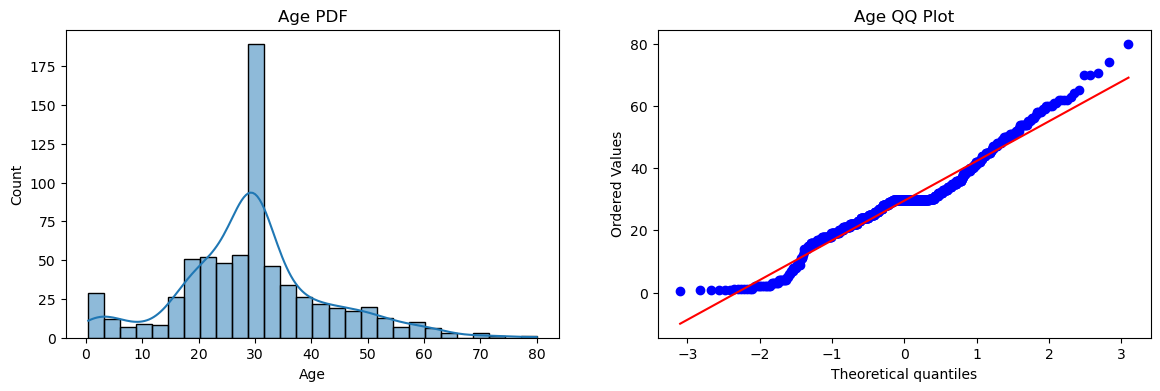

In [179]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(x_train['Age'],kde=True)
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(x_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

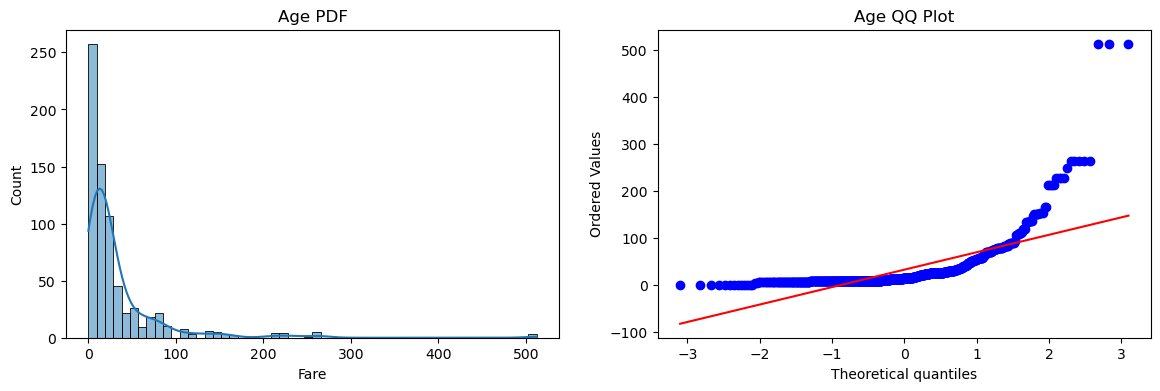

In [180]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(x_train['Fare'],kde=True)
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(x_train['Fare'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

In [181]:
clf = LogisticRegression()
clf1 =DecisionTreeClassifier()

In [182]:
clf.fit(x_train,y_train)
clf1.fit(x_train,y_train)

pred= clf.predict(x_test)
pred1= clf1.predict(x_test)

print('accuracy_LR',accuracy_score(pred,y_test))
print('accuracy_DT',accuracy_score(pred1,y_test))

accuracy_LR 0.6480446927374302
accuracy_DT 0.664804469273743


In [183]:
trf = FunctionTransformer(func=np.log1p)

In [184]:
x_train_transformed = trf.fit_transform(x_train)
x_test_transformed = trf.transform(x_test)

In [185]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()
clf.fit(x_train_transformed,y_train)
clf2.fit(x_train_transformed,y_train)

pred= clf.predict(x_test_transformed)
pred1= clf1.predict(x_test_transformed)

print('accuracy_LR',accuracy_score(y_test,pred))
print('accuracy_DT',accuracy_score(y_test,pred1))

accuracy_LR 0.6815642458100558
accuracy_DT 0.4134078212290503


In [186]:

X_transformed = trf.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6588139825218476


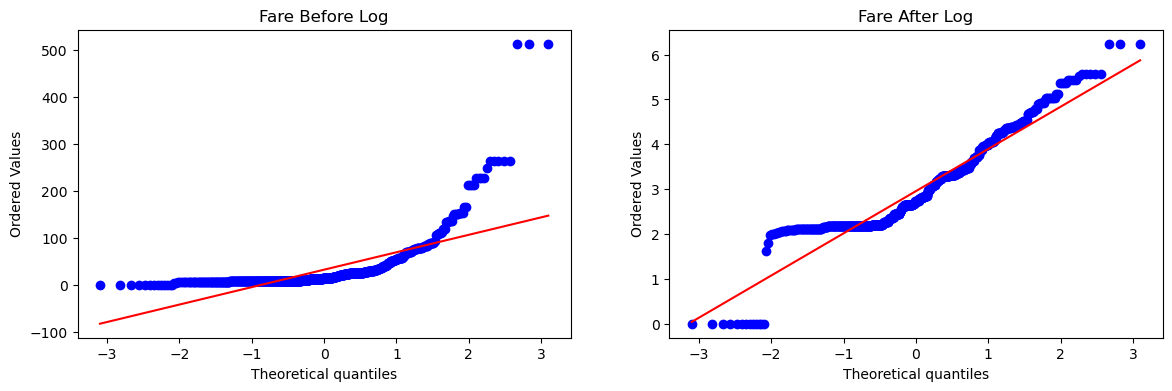

In [187]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(x_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(x_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()

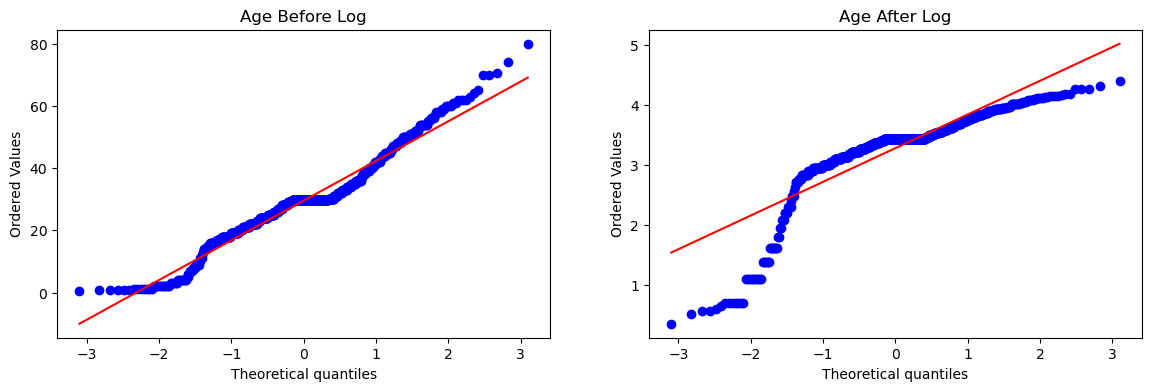

In [188]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(x_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(x_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

In [189]:
def apply_transform(transform):
    x = df.iloc[:,1:3]
    y = df.iloc[:,0]

In [190]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6431335830212235


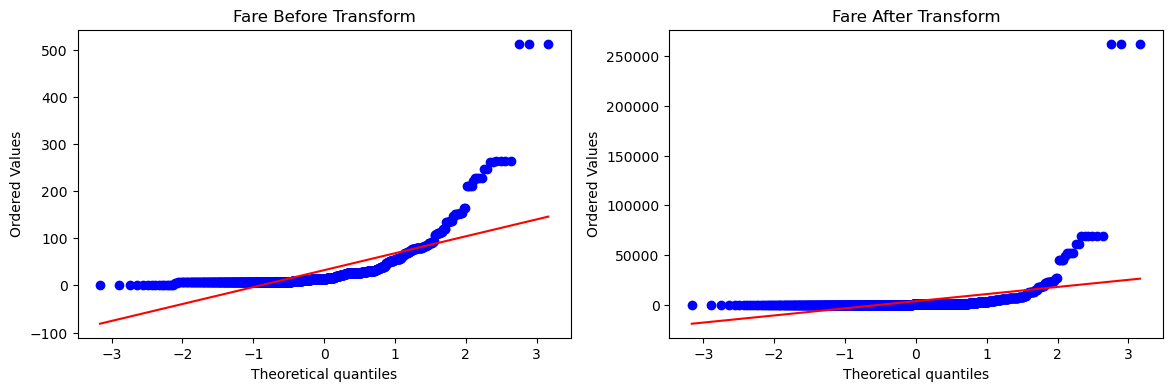

In [195]:
apply_transform(lambda x:x**2)